In [11]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import re

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import joblib

## Load Dataset

In [67]:
import pandas as pd
import numpy as np

# قراءة الداتا سيت
df = pd.read_csv("/content/house_prices.csv")

print("Shape:", df.shape)
display(df.head())
df.info()
display(df.describe())

# فحص القيم المفقودة لكل عمود
missing = df.isna().mean().sort_values(ascending=False)
print("Missing values ratio:\n", missing)

Shape: (187531, 21)


,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

,Index,Price (in rupees),Dimensions,Plot Area
count,187531.000000,1.698660e+05,0.0,0.0
mean,93765.000000,7.583772e+03,NaN,NaN
std,54135.681003,2.724171e+04,NaN,NaN
min,0.000000,0.000000e+00,NaN,NaN
25%,46882.500000,4.297000e+03,NaN,NaN
50%,93765.000000,6.034000e+03,NaN,NaN
75%,140647.500000,9.450000e+03,NaN,NaN
max,187530.000000,6.700000e+06,NaN,NaN


Missing values ratio:
 Plot Area            1.000000
Dimensions           1.000000
Society              0.584853
Super Area           0.574225
Car Parking          0.551146
overlooking          0.434254
Carpet Area          0.430185
facing               0.374514
Ownership            0.349366
Balcony              0.260944
Price (in rupees)    0.094198
Floor                0.037738
Description          0.016120
Furnishing           0.015448
Bathroom             0.004415
Status               0.003279
Transaction          0.000443
Amount(in rupees)    0.000000
Title                0.000000
Index                0.000000
location             0.000000
dtype: float64


In [17]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [18]:
df.isnull().sum()

,0
Index,0
Title,0
Description,1434
Amount(in rupees),0
Price (in rupees),7571
location,0
Carpet Area,43425
Status,340
Floor,4069
Transaction,33


In [19]:
(df.isnull().sum()/len(df))*100

,0
Index,0.000000
Title,0.000000
Description,1.653979
Amount(in rupees),0.000000
Price (in rupees),8.732411
location,0.000000
Carpet Area,50.086505
Status,0.392157
Floor,4.693195
Transaction,0.038062


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
df.nunique()

,0
Index,86700
Title,11531
Description,20016
Amount(in rupees),1326
Price (in rupees),7678
location,11
Carpet Area,1907
Status,1
Floor,865
Transaction,4


## Data Summary

The dataset contains around 187 thousand rows.

The dataset has both numerical and categorical features.

Some columns contain many missing values.

The target variable is Amount(in rupees).

The dataset requires data cleaning before training.

# Data Cleaning

In [22]:
df_clean = df.copy()

In [23]:
df_clean.drop(columns=[
    "Index",
    "Title",
    "Description",
    "Dimensions",
    "Plot Area"
], inplace=True)

In [24]:
df_clean.columns

Index(['Amount(in rupees)', 'Price (in rupees)', 'location', 'Carpet Area',
       'Status', 'Floor', 'Transaction', 'Furnishing', 'facing', 'overlooking',
       'Society', 'Bathroom', 'Balcony', 'Car Parking', 'Ownership',
       'Super Area'],
      dtype='object')

In [25]:
def clean_price(price):

    if pd.isna(price):
        return np.nan

    price = str(price).strip()

    if "Lac" in price:
        return float(price.replace("Lac","")) * 100000

    elif "Cr" in price:
        return float(price.replace("Cr","")) * 10000000

    else:
        return np.nan

In [26]:
df_clean["price_clean"] = df_clean["Amount(in rupees)"].apply(clean_price)

In [27]:
df_clean[
    ["Amount(in rupees)",
     "price_clean"]
].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [28]:
def clean_area(area):

    if pd.isna(area):
        return np.nan

    area = str(area)

    number = re.findall(r"\d+\.?\d*", area)

    if len(number)==0:
        return np.nan

    number=float(number[0])

    if "sqm" in area.lower():
        number*=10.764

    return number

In [29]:
df_clean["carpet_area_sqft"] = df_clean["Carpet Area"].apply(clean_area)

In [30]:
df_clean[
[
"Carpet Area",
"carpet_area_sqft"
]
].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [31]:
def clean_floor(floor):

    if pd.isna(floor):
        return np.nan

    floor=str(floor)

    match=re.search(r"\d+",floor)

    if match:
        return int(match.group())

    if "Ground" in floor:
        return 0

    return np.nan

In [32]:
df_clean["Floor"]=df_clean["Floor"].apply(clean_floor)

In [33]:
df_clean["Floor"].head(20)

,Floor
0,10.0
1,3.0
2,10.0
3,1.0
4,20.0
5,2.0
6,4.0
7,7.0
8,2.0
9,3.0


In [34]:
df_clean.head()

,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,price_clean,carpet_area_sqft
0,42 Lac,6000.0,thane,500 sqft,Ready to Move,10.0,Resale,Unfurnished,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,4200000.0,500.0
1,98 Lac,13799.0,thane,473 sqft,Ready to Move,3.0,Resale,Semi-Furnished,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,9800000.0,473.0
2,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10.0,Resale,Unfurnished,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,14000000.0,779.0
3,25 Lac,NaN,thane,530 sqft,Ready to Move,1.0,Resale,Unfurnished,NaN,NaN,NaN,1,1,NaN,NaN,NaN,2500000.0,530.0
4,1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20.0,Resale,Unfurnished,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,16000000.0,635.0


In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 86700 entries, 0 to 86699
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Amount(in rupees)  86700 non-null  object 
 1   Price (in rupees)  79129 non-null  float64
 2   location           86700 non-null  object 
 3   Carpet Area        43275 non-null  object 
 4   Status             86360 non-null  object 
 5   Floor              82631 non-null  float64
 6   Transaction        86667 non-null  object 
 7   Furnishing         84666 non-null  object 
 8   facing             52818 non-null  object 
 9   overlooking        45229 non-null  object 
 10  Society            28541 non-null  object 
 11  Bathroom           86285 non-null  object 
 12  Balcony            58986 non-null  object 
 13  Car Parking        38341 non-null  object 
 14  Ownership          53536 non-null  object 
 15  Super Area         42685 non-null  object 
 16  price_clean        826

In [36]:
df_clean.drop(columns=[
    "Amount(in rupees)",
    "Price (in rupees)",
    "Carpet Area",
    "Society",
    "Super Area"
], inplace=True)

In [37]:
df_clean.isnull().sum()

,0
location,0
Status,340
Floor,4069
Transaction,33
Furnishing,2034
facing,33882
overlooking,41471
Bathroom,415
Balcony,27714
Car Parking,48359


In [38]:
df_clean["Bathroom"] = pd.to_numeric(df_clean["Bathroom"], errors="coerce")

df_clean["Balcony"] = pd.to_numeric(df_clean["Balcony"], errors="coerce")

In [39]:
numeric_columns = [
    "Floor",
    "Bathroom",
    "Balcony",
    "carpet_area_sqft"
]

for col in numeric_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

In [40]:
categorical_columns = [
    "Status",
    "Transaction",
    "Furnishing",
    "facing",
    "overlooking",
    "Ownership"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

In [41]:
df_clean = df_clean.dropna(subset=["price_clean"])

In [42]:
df_clean.isnull().sum()

,0
location,0
Status,0
Floor,0
Transaction,0
Furnishing,0
facing,0
overlooking,0
Bathroom,0
Balcony,0
Car Parking,45537


In [43]:
df_clean["location"].nunique()

11

In [44]:
df_clean["Furnishing"].value_counts()

,count
Furnishing,
Semi-Furnished,40755
Unfurnished,35401
Furnished,6445
Semi-Furnis,1


EDA (Visualization)

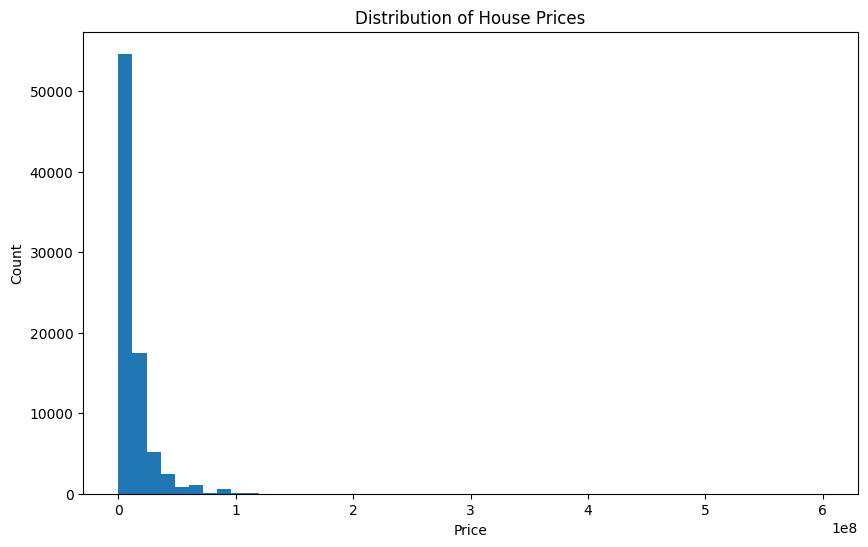

In [45]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["price_clean"], bins=50)

plt.title("Distribution of House Prices")

plt.xlabel("Price")

plt.ylabel("Count")

plt.show()

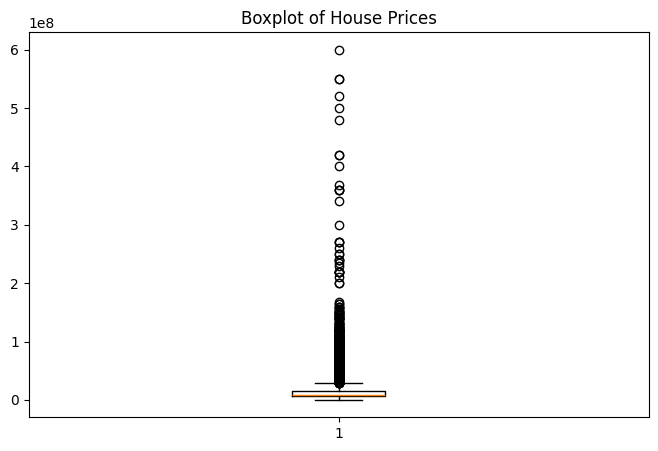

In [46]:
plt.figure(figsize=(8,5))

plt.boxplot(df_clean["price_clean"])

plt.title("Boxplot of House Prices")

plt.show()

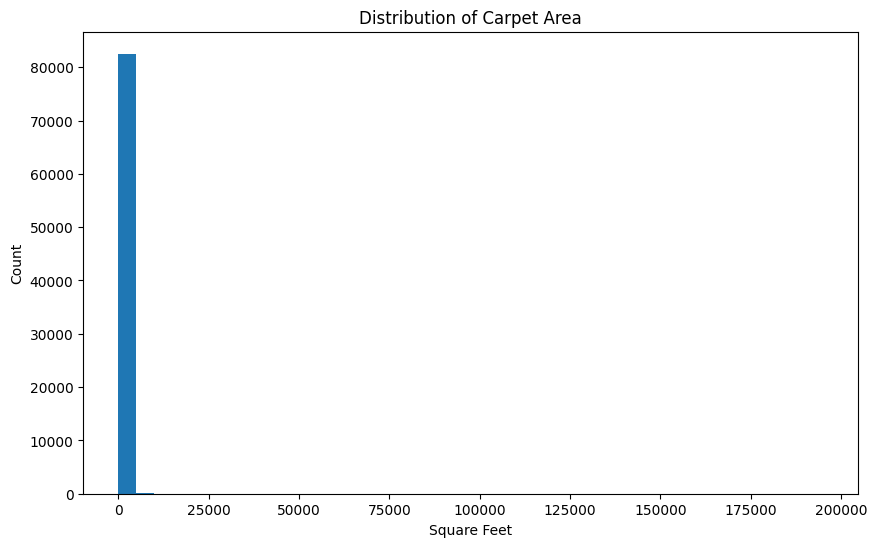

In [47]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["carpet_area_sqft"], bins=40)

plt.title("Distribution of Carpet Area")

plt.xlabel("Square Feet")

plt.ylabel("Count")

plt.show()

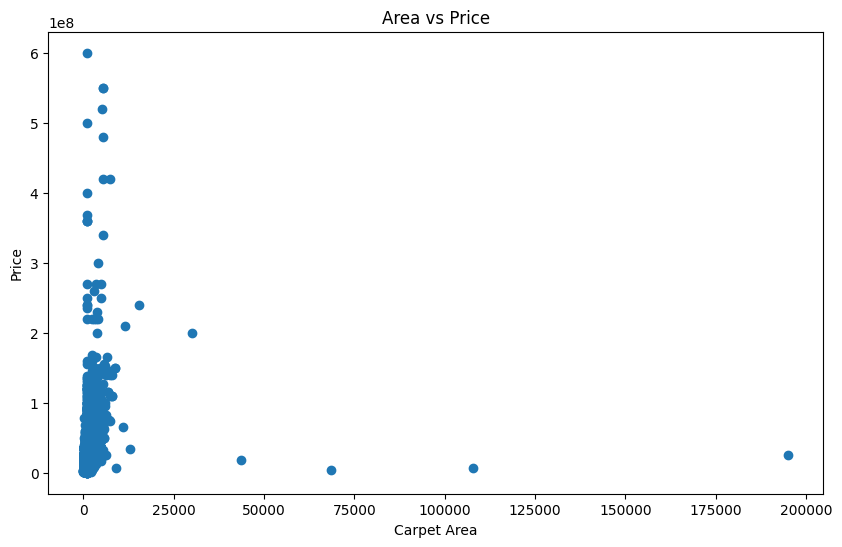

In [48]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["carpet_area_sqft"],
    df_clean["price_clean"]
)

plt.xlabel("Carpet Area")

plt.ylabel("Price")

plt.title("Area vs Price")

plt.show()

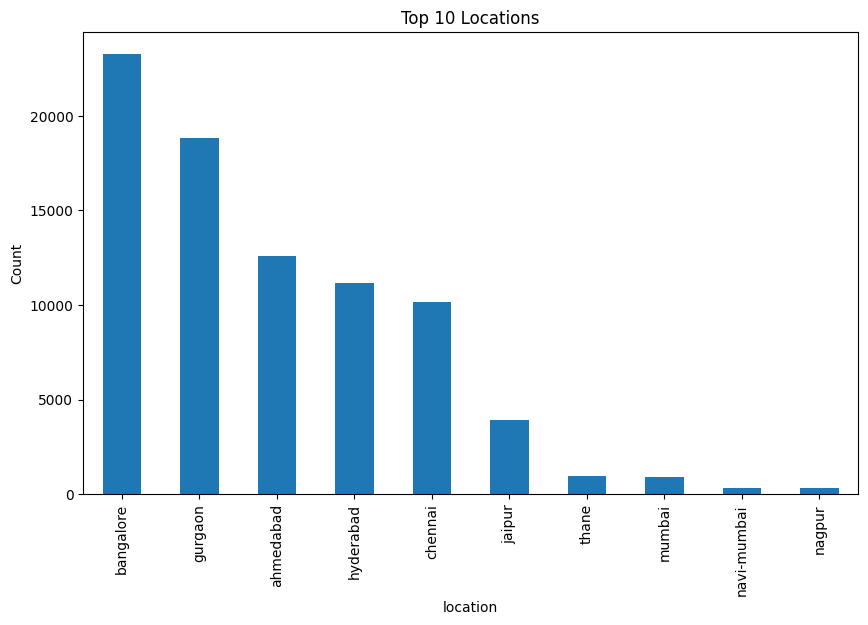

In [49]:
top_locations = df_clean["location"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_locations.plot(kind="bar")

plt.title("Top 10 Locations")

plt.ylabel("Count")

plt.show()

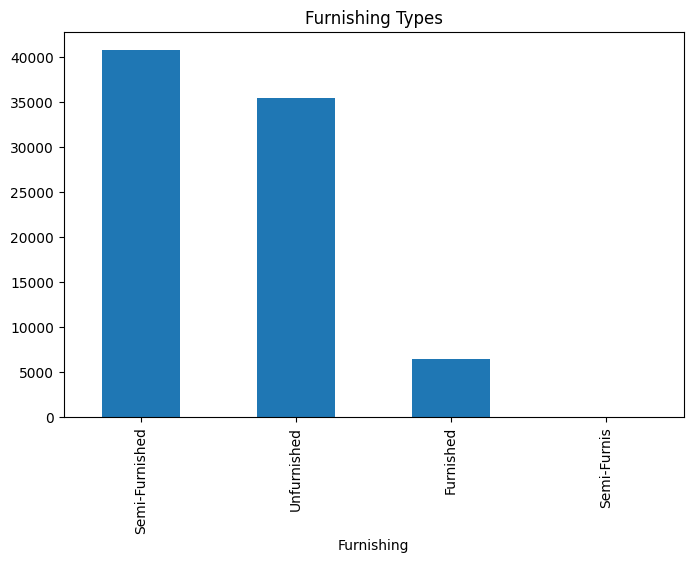

In [50]:
plt.figure(figsize=(8,5))

df_clean["Furnishing"].value_counts().plot(kind="bar")

plt.title("Furnishing Types")

plt.show()

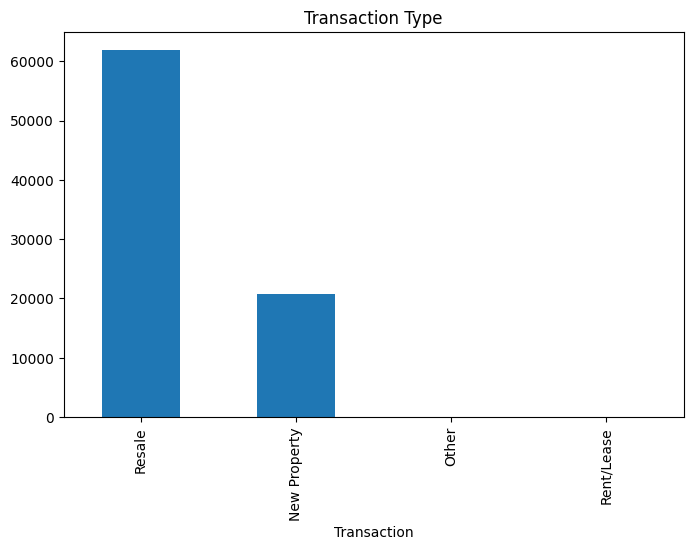

In [51]:
plt.figure(figsize=(8,5))

df_clean["Transaction"].value_counts().plot(kind="bar")

plt.title("Transaction Type")

plt.show()

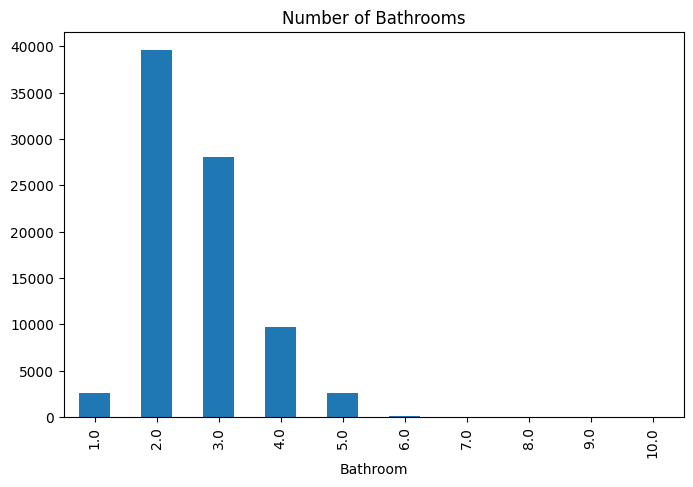

In [52]:
plt.figure(figsize=(8,5))

df_clean["Bathroom"].value_counts().sort_index().plot(kind="bar")

plt.title("Number of Bathrooms")

plt.show()

In [53]:
numeric_df = df_clean.select_dtypes(include=np.number)

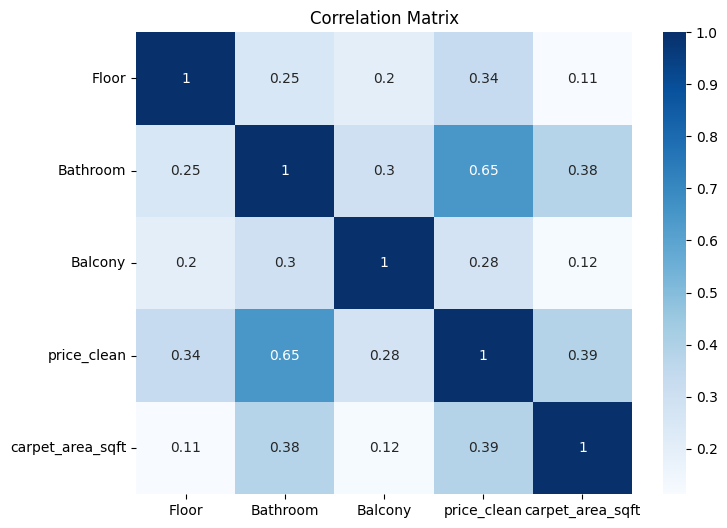

In [54]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Matrix")

plt.show()

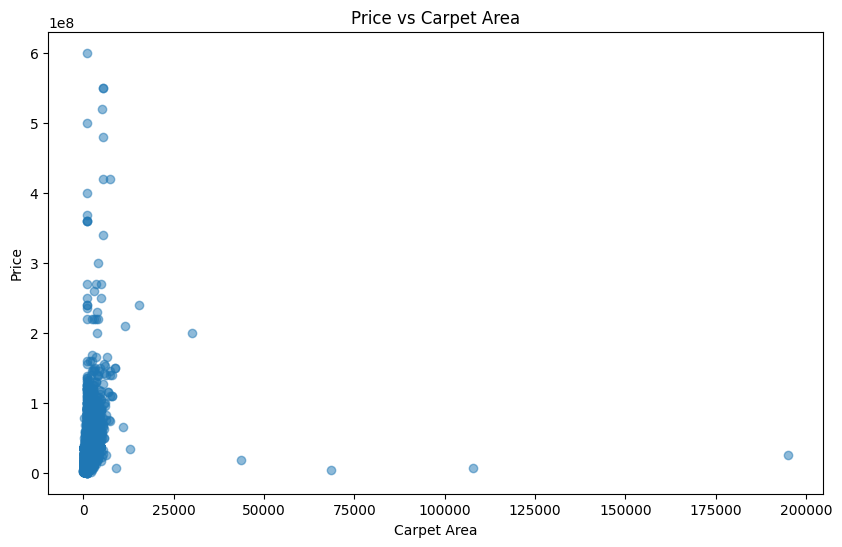

In [55]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_clean["carpet_area_sqft"],
    df_clean["price_clean"],
    alpha=0.5
)

plt.title("Price vs Carpet Area")

plt.xlabel("Carpet Area")

plt.ylabel("Price")

plt.show()

In [56]:
df_clean["Car Parking"].value_counts().head(20)

,count
Car Parking,
1 Covered,17041
2 Covered,7775
"1 Covered,",5420
"2 Covered,",2548
1 Open,2223
2 Open,626
34 Covered,572
402 Covered,314
3 Covered,259


In [57]:
Q1 = df_clean["price_clean"].quantile(0.25)
Q3 = df_clean["price_clean"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [58]:
df_clean = df_clean[
    (df_clean["price_clean"] >= lower) &
    (df_clean["price_clean"] <= upper)
]

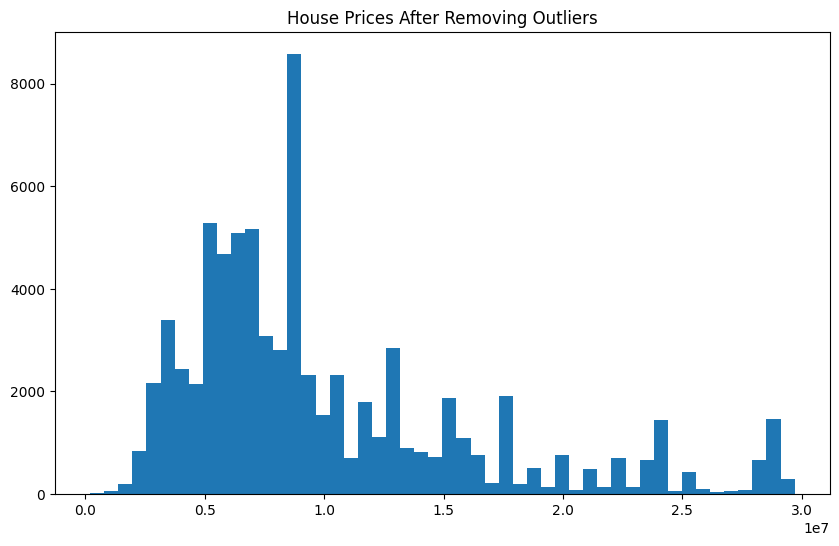

In [59]:
plt.figure(figsize=(10,6))

plt.hist(df_clean["price_clean"], bins=50)

plt.title("House Prices After Removing Outliers")

plt.show()

In [60]:
def clean_parking(x):
    if pd.isna(x):
        return np.nan

    import re

    match = re.search(r"\d+", str(x))

    if match:
        return int(match.group())

    return np.nan

In [61]:
df_clean["Car Parking"] = df_clean["Car Parking"].apply(clean_parking)

In [62]:
df_clean["Car Parking"] = df_clean["Car Parking"].fillna(
    df_clean["Car Parking"].median()
)

In [63]:
df_clean["Car Parking"].value_counts().head(10)

,count
Car Parking,
1.0,67961
2.0,6297
34.0,572
402.0,313
3.0,60
4.0,20
15.0,15
12.0,8
8.0,7


In [64]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 75368 entries, 0 to 86699
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   location          75368 non-null  object 
 1   Status            75368 non-null  object 
 2   Floor             75368 non-null  float64
 3   Transaction       75368 non-null  object 
 4   Furnishing        75368 non-null  object 
 5   facing            75368 non-null  object 
 6   overlooking       75368 non-null  object 
 7   Bathroom          75368 non-null  float64
 8   Balcony           75368 non-null  float64
 9   Car Parking       75368 non-null  float64
 10  Ownership         75368 non-null  object 
 11  price_clean       75368 non-null  float64
 12  carpet_area_sqft  75368 non-null  float64
dtypes: float64(6), object(7)
memory usage: 8.1+ MB


In [65]:
df_clean.isnull().sum()

,0
location,0
Status,0
Floor,0
Transaction,0
Furnishing,0
facing,0
overlooking,0
Bathroom,0
Balcony,0
Car Parking,0


# Part 1 : Features & Target

In [68]:
X = df_clean.drop("price_clean", axis=1)

y = df_clean["price_clean"]

print(X.shape)
print(y.shape)

(75368, 12)
(75368,)


# Part 2 : Train Test Split

In [69]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,
    test_size=0.2,
    random_state=42

)

print(X_train.shape)
print(X_test.shape)

(60294, 12)
(15074, 12)


# Part 3 : Numerical & Categorical Columns

In [70]:
numeric_features = X.select_dtypes(include=np.number).columns

categorical_features = X.select_dtypes(include="object").columns

print(numeric_features)

print(categorical_features)

Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='object')
Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='object')


# Part 4 : Numerical Pipeline

In [71]:
numeric_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="median")),

        ("scaler", StandardScaler())

    ]

)

# Part 5 : Categorical Pipeline

In [72]:
categorical_transformer = Pipeline(

    steps=[

        ("imputer", SimpleImputer(strategy="most_frequent")),

        ("encoder", OneHotEncoder(handle_unknown="ignore"))

    ]

)

# Part 6 : Column Transformer

In [73]:
preprocessor = ColumnTransformer(

    transformers=[

        ("num", numeric_transformer, numeric_features),

        ("cat", categorical_transformer, categorical_features)

    ]

)

# Part 7 : Linear Regression

In [74]:
linear_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        ("model", LinearRegression())

    ]

)

# Part 8 : Train

In [75]:
linear_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='object'))])),
                ('model', LinearRegression())])

# Part 9 : Prediction

In [76]:
y_pred_linear = linear_model.predict(X_test)

# Part 10 : Evaluation

In [77]:
mae = mean_absolute_error(y_test, y_pred_linear)

mse = mean_squared_error(y_test, y_pred_linear)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

Linear Regression
MAE : 2714084.5502351723
RMSE : 3835447.8964321245
R2 : 0.6165528932406755


# Random Forest

In [78]:
rf_model = Pipeline(

    steps=[

        ("preprocessor", preprocessor),

        (

            "model",

            RandomForestRegressor(

                n_estimators=150,

                random_state=42

            )

        )

    ]

)

# Train

In [79]:
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Floor', 'Bathroom', 'Balcony', 'Car Parking', 'carpet_area_sqft'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['location', 'Status', 'Transaction', 'Furnishing', 'facing',
       'overlooking', 'Ownership'],
      dtype='object'))])),
                ('model',
                 RandomForestRegressor(n_estimators=150, random_state=42))])

# Prediction

In [81]:
y_pred_rf = rf_model.predict(X_test)

# Evaluation

In [82]:
mae = mean_absolute_error(y_test, y_pred_rf)

mse = mean_squared_error(y_test, y_pred_rf)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred_rf)

print("Random Forest")

print("MAE :", mae)

print("RMSE :", rmse)

print("R2 :", r2)

Random Forest
MAE : 745734.7709532201
RMSE : 1959871.4278570097
R2 : 0.8998782449899498


# Compare Models

In [83]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest"

    ],

    "MAE":[

        mean_absolute_error(y_test,y_pred_linear),

        mean_absolute_error(y_test,y_pred_rf)

    ],

    "RMSE":[

        np.sqrt(mean_squared_error(y_test,y_pred_linear)),

        np.sqrt(mean_squared_error(y_test,y_pred_rf))

    ],

    "R2":[

        r2_score(y_test,y_pred_linear),

        r2_score(y_test,y_pred_rf)

    ]

})

results

,Model,MAE,RMSE,R2
0,Linear Regression,2.714085e+06,3.835448e+06,0.616553
1,Random Forest,7.457348e+05,1.959871e+06,0.899878


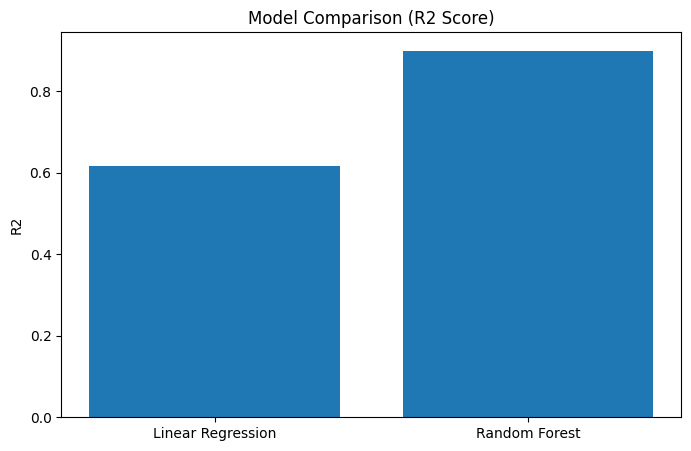

In [84]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["R2"])

plt.title("Model Comparison (R2 Score)")

plt.ylabel("R2")

plt.show()

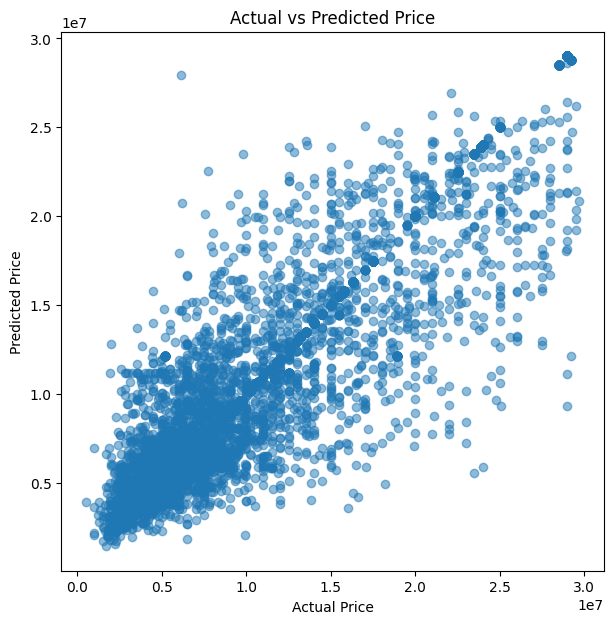

In [85]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    y_pred_rf,

    alpha=0.5

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.show()

# Save Model

In [86]:
joblib.dump(

    rf_model,

    "house_price_model.pkl"

)

['house_price_model.pkl']

# Test Model

In [87]:
sample = X.iloc[[0]]

prediction = rf_model.predict(sample)

print("Predicted Price :", prediction[0])

print("Actual Price :", y.iloc[0])

Predicted Price : 4376900.0
Actual Price : 4200000.0


In [88]:
print("Model Score :", linear_model.score(X_test,y_test))

Model Score : 0.6165528932406755


In [89]:
print("Model Score :", rf_model.score(X_test,y_test))

Model Score : 0.8998782449899498


# 1️⃣ مقارنة بين Actual و Predicted

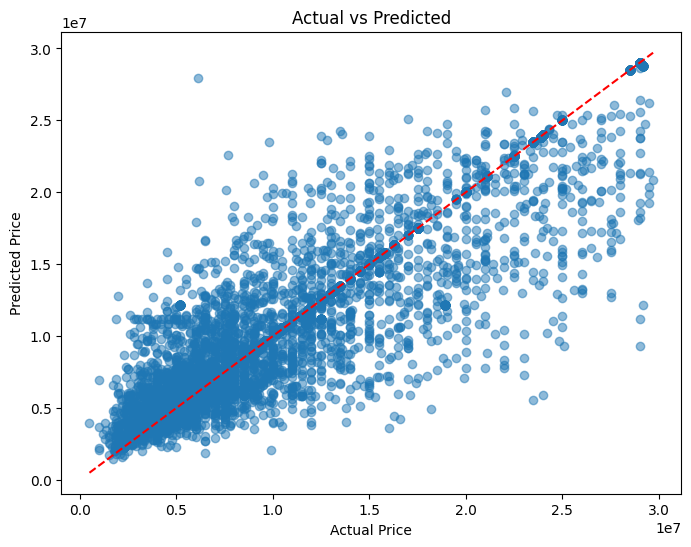

In [90]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred_rf,
    alpha=0.5
)

plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

# 2️⃣ Residual Plot

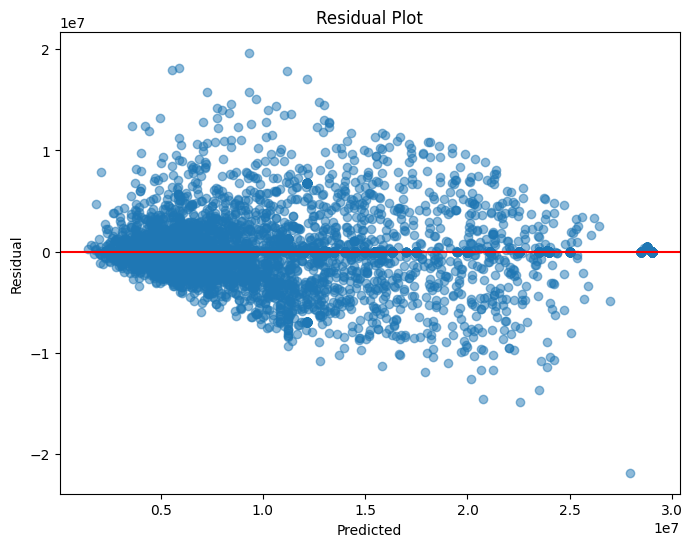

In [91]:
residuals = y_test - y_pred_rf

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred_rf,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

# 3️⃣ Feature Importance

In [92]:
encoder = preprocessor.named_transformers_["cat"]["encoder"]

cat_features = encoder.get_feature_names_out(categorical_features)

feature_names = np.concatenate(
    [
        numeric_features,
        cat_features
    ]
)

importance = rf_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame({

    "Feature":feature_names,

    "Importance":importance

})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
4,carpet_area_sqft,0.421839
1,Bathroom,0.178772
0,Floor,0.062477
8,location_gurgaon,0.044699
2,Balcony,0.033799
6,location_bangalore,0.032144
27,facing_North - East,0.026090
3,Car Parking,0.025176
20,Transaction_Resale,0.018520
24,Furnishing_Unfurnished,0.017132


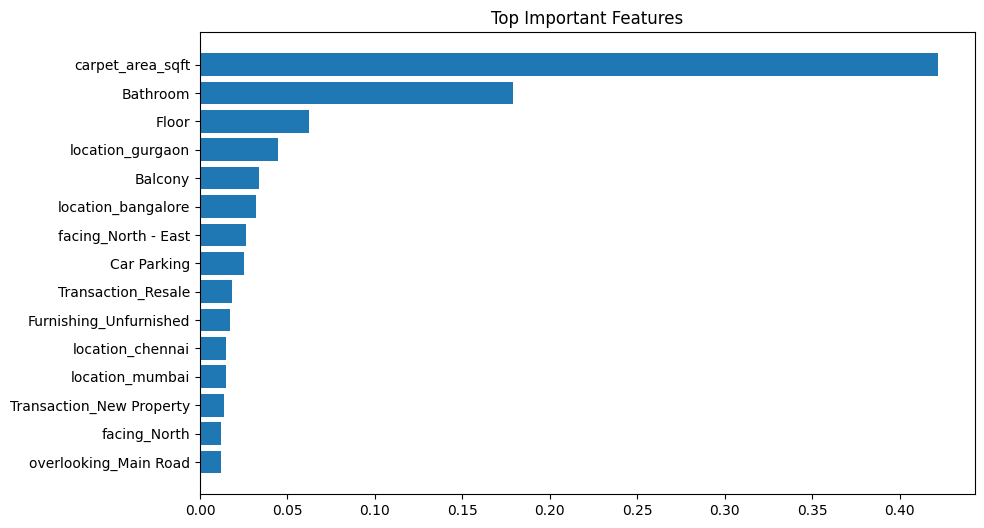

In [93]:
plt.figure(figsize=(10,6))

plt.barh(

    importance_df.head(15)["Feature"],

    importance_df.head(15)["Importance"]

)

plt.title("Top Important Features")

plt.gca().invert_yaxis()

plt.show()

# 4 Load Model

In [94]:
loaded_model = joblib.load(
    "house_price_model.pkl"
)

# Prediction

In [95]:
sample = X.iloc[[20]]

prediction = loaded_model.predict(sample)

print(prediction)

[14776000.]


# Conclusion

• Data cleaning was successfully completed.

• Missing values were handled.

• Outliers were removed.

• Features were encoded and scaled.

• Two regression models were trained.

• Random Forest achieved better performance than Linear Regression.

# • The trained model was saved using Joblib and is ready for deployment.